In [33]:
%matplotlib widget

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from tqdm import tqdm

import nibabel as nib
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

import random

from torchvision.models.densenet import densenet121

import cv2

In [3]:
d_path = "../data/uncompressed/MosMedData Chest CT Scans with COVID-19 Related Findings COVID19_1110 1.0/studies"
d_path = Path(d_path)

ct_0 = d_path / "CT-0"
ct_1 = d_path / "CT-1"
ct_2 = d_path / "CT-2"
ct_3 = d_path / "CT-3"
ct_4 = d_path / "CT-4"

ct_0_files = list(ct_0.glob("*.nii"))
ct_1_files = list(ct_1.glob("*.nii"))
ct_2_files = list(ct_2.glob("*.nii"))
ct_3_files = list(ct_3.glob("*.nii"))
ct_4_files = list(ct_4.glob("*.nii"))
print(f"CT-0 files: {len(ct_0_files)}")
print(f"CT-1 files: {len(ct_1_files)}")
print(f"CT-2 files: {len(ct_2_files)}")
print(f"CT-3 files: {len(ct_3_files)}")
print(f"CT-4 files: {len(ct_4_files)}")

print(f"CT-0 size: {sum(f.stat().st_size for f in ct_0_files) / 1e6:.2f} MB")
print(f"CT-1 size: {sum(f.stat().st_size for f in ct_1_files) / 1e6:.2f} MB")
print(f"CT-2 size: {sum(f.stat().st_size for f in ct_2_files) / 1e6:.2f} MB")
print(f"CT-3 size: {sum(f.stat().st_size for f in ct_3_files) / 1e6:.2f} MB")
print(f"CT-4 size: {sum(f.stat().st_size for f in ct_4_files) / 1e6:.2f} MB")

CT-0 files: 254
CT-1 files: 684
CT-2 files: 125
CT-3 files: 45
CT-4 files: 2
CT-0 size: 5814.97 MB
CT-1 size: 14797.75 MB
CT-2 size: 2715.33 MB
CT-3 size: 964.18 MB
CT-4 size: 40.90 MB


In [16]:
slices = []
y = []
sample_size_0 = 2000
sample_size_1 = 500

for cat in [ct_0_files, ct_1_files, ct_2_files, ct_3_files]:
    temp = []
    for f in tqdm(cat):
        img = nib.load(f)
        data = img.get_fdata()
        for i in range(data.shape[-1]):
            slice = data[:, :, i]
            slice = cv2.resize(slice, (256, 256))
            temp.append(slice)
    if cat == ct_0_files:
        slices.extend(random.sample(temp, sample_size_0))
        y.extend([0] * sample_size_0)
    else:
        slices.extend(random.sample(temp, sample_size_1))
        y.extend([1] * sample_size_1)

slices = np.array(slices)
labels = np.array(y)
print(f"Slices shape: {slices.shape}")
print(f"y shape: {labels.shape}")

100%|██████████| 45/45 [00:04<00:00, 10.80it/s]


Slices shape: (3500, 256, 256)
y shape: (3500,)


In [21]:
basic_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

augmentation_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.2),
    ])

all_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

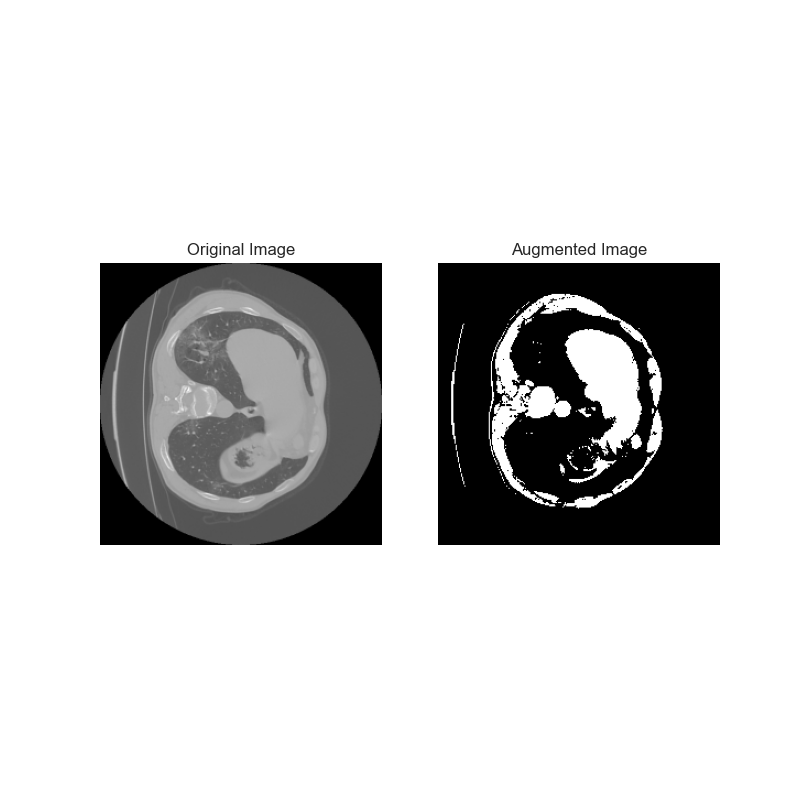

In [17]:
sample_idx = random.randint(0, len(slices) - 1)
sample_img = slices[sample_idx]
augmented = augmentation_transform(image=sample_img)["image"]

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(augmented, cmap="gray")
plt.axis("off")

plt.show()

In [22]:
for i in tqdm(range(slices.shape[0])):
    slices[i] = all_transform(image=slices[i])["image"].numpy().squeeze()

100%|██████████| 3500/3500 [00:02<00:00, 1504.22it/s]


In [23]:
class CTDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image=image)["image"]
        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        return image


dataset = CTDataset(slices, labels, transform=None)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [38]:
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[-1] = nn.Linear(in_features=768, out_features=2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

n_epochs = 10

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
criterion.to(device)

In [ ]:
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total

    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

  0%|          | 0/110 [00:00<?, ?it/s]